# SPY Classification with Logistic Regression

This repository contains a personal implementation of a binary classification workflow on SPY market data using Python.

## What it does
- Downloads SPY price data with `yfinance`
- Engineers rolling return features
- Creates a directional target
- Splits train and test samples
- Scales features
- Fits a logistic regression classifier
- Evaluates results with accuracy, confusion matrix, and ROC curve


In [14]:
import numpy as np
import yfinance as yf

# Getting historical market data from SPY (ETF) (SPY)
df = yf.download("SPY", start="2000-01-01", end="2026-01-01")
df['Adj Close']= df ['Close']
df["Ret"] = df["Adj Close"].pct_change()

name = "Ret"
df["Ret10_i"] = (
    df[name].rolling(10).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 10) - 1))
)
df["Ret25_i"] = (
    df[name].rolling(25).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 25) - 1))
)
df["Ret60_i"] = (
    df[name].rolling(60).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 60) - 1))
)
df["Ret120_i"] = (
    df[name].rolling(120).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 120) - 1))
)
df["Ret240_i"] = (
    df[name].rolling(240).apply(lambda x: 100 * ((np.prod(1 + x)) ** (1 / 240) - 1))
)

del df["Open"]
del df["Close"]
del df["High"]
del df["Low"]
del df["Volume"]
del df["Adj Close"]

df = df.dropna()
df.tail(10)

/tmp/ipykernel_187/888321288.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SPY", start="2000-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Ret,Ret10_i,Ret25_i,Ret60_i,Ret120_i,Ret240_i
Ticker,,,,,,
Date,,,,,,
2025-12-17,-0.011004,-0.184150,-0.068495,0.020458,0.075577,0.061308
2025-12-18,0.007551,-0.116332,-0.040644,0.038312,0.077873,0.059263
2025-12-19,0.009063,-0.045139,0.062391,0.061068,0.085668,0.060630
2025-12-22,0.006230,0.047055,0.087907,0.061898,0.087075,0.067960
2025-12-23,0.004570,0.101330,0.143652,0.064823,0.084331,0.069252
2025-12-24,0.003518,0.070315,0.191510,0.064409,0.093498,0.077132
2025-12-26,-0.000101,0.046045,0.175652,0.058567,0.093871,0.076443
2025-12-29,-0.003564,0.118506,0.222905,0.050694,0.085906,0.074381


In [15]:
df["Ret25"] = df["Ret25_i"].shift(-25)
df = df.dropna()
df.tail(10)

Price,Ret,Ret10_i,Ret25_i,Ret60_i,Ret120_i,Ret240_i,Ret25
Ticker,,,,,,,
Date,,,,,,,
2025-11-11,0.002289,-0.059250,0.082160,0.104475,0.136984,0.060758,-0.068495
2025-11-12,0.000556,-0.058490,0.060588,0.114480,0.137119,0.058818,-0.040644
2025-11-13,-0.016594,-0.115183,0.005241,0.091001,0.128871,0.053108,0.062391
2025-11-14,-0.000164,-0.149523,0.114251,0.097434,0.111566,0.050458,0.087907
2025-11-17,-0.009316,-0.261643,0.015836,0.056402,0.108598,0.045809,0.143652
2025-11-18,-0.008397,-0.226813,-0.013006,0.049695,0.098277,0.042101,0.191510
2025-11-19,0.003863,-0.222860,-0.015302,0.049157,0.102427,0.041127,0.175652
2025-11-20,-0.015242,-0.268470,-0.049396,0.019754,0.084930,0.035412,0.222905


In [16]:
df["Output"] = df["Ret25"].apply(np.sign)
del df["Ret25"]
df.tail(10)

Price,Ret,Ret10_i,Ret25_i,Ret60_i,Ret120_i,Ret240_i,Output
Ticker,,,,,,,
Date,,,,,,,
2025-11-11,0.002289,-0.059250,0.082160,0.104475,0.136984,0.060758,-1.0
2025-11-12,0.000556,-0.058490,0.060588,0.114480,0.137119,0.058818,-1.0
2025-11-13,-0.016594,-0.115183,0.005241,0.091001,0.128871,0.053108,1.0
2025-11-14,-0.000164,-0.149523,0.114251,0.097434,0.111566,0.050458,1.0
2025-11-17,-0.009316,-0.261643,0.015836,0.056402,0.108598,0.045809,1.0
2025-11-18,-0.008397,-0.226813,-0.013006,0.049695,0.098277,0.042101,1.0
2025-11-19,0.003863,-0.222860,-0.015302,0.049157,0.102427,0.041127,1.0
2025-11-20,-0.015242,-0.268470,-0.049396,0.019754,0.084930,0.035412,1.0


In [17]:
df.describe()

Price,Ret,Ret10_i,Ret25_i,Ret60_i,Ret120_i,Ret240_i,Output
Ticker,,,,,,,
count,6274.000000,6274.000000,6274.000000,6274.000000,6274.000000,6274.000000,6274.000000
mean,0.000397,0.033275,0.032916,0.032270,0.031201,0.030296,0.306344
std,0.012121,0.337313,0.210166,0.129562,0.094245,0.069144,0.951997
min,-0.109424,-3.067445,-1.622891,-0.875641,-0.493507,-0.282909,-1.000000
25%,-0.004437,-0.113657,-0.060353,-0.024642,-0.011378,0.007040,-1.000000
50%,0.000701,0.071470,0.066864,0.056764,0.048009,0.046690,1.000000
75%,0.005942,0.217341,0.156144,0.112401,0.087396,0.072388,1.000000
max,0.145197,1.973284,0.997339,0.559837,0.359182,0.231672,1.000000


In [18]:
X, y = df.iloc[:, 0:-1], df.iloc[:, -1]
print(X.shape, y.shape)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=int(len(y) * 0.5), shuffle=False
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6274, 6) (6274,)
(3137, 6) (3137, 6) (3137,) (3137,)


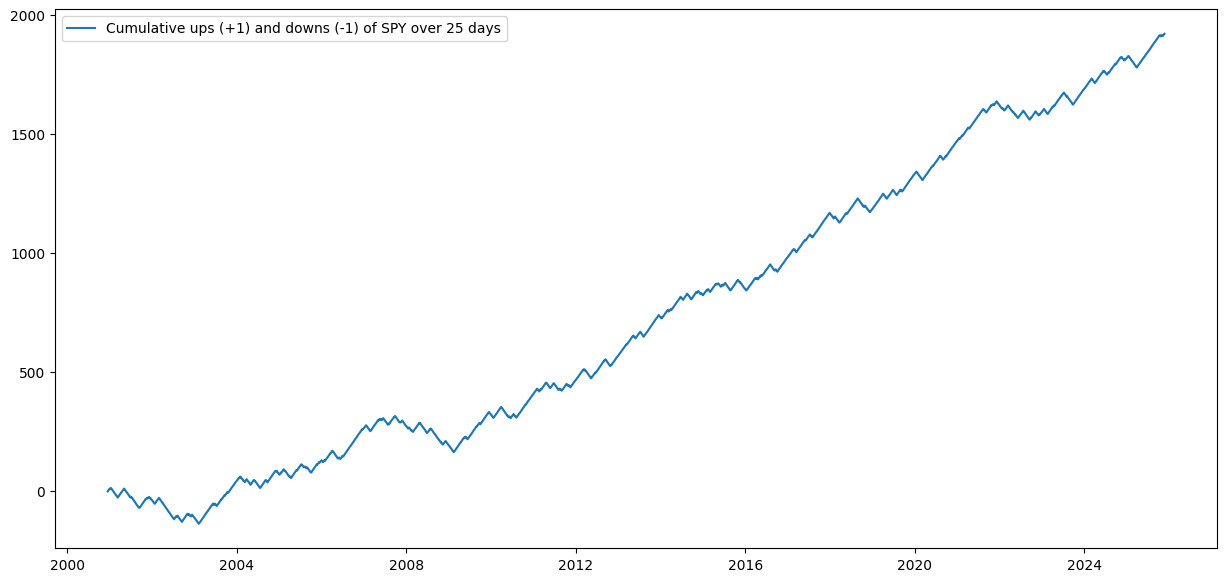

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(
    df.index,
    np.cumsum(y),
    label="Cumulative ups (+1) and downs (-1) of SPY over 25 days",
)
legend = plt.legend(loc="upper left")
# plt.ylim([-1.25,1.25])
plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler_input = MinMaxScaler(feature_range=(-1, 1))
scaler_input.fit(X_train)
X_train = scaler_input.transform(X_train)
X_test = scaler_input.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

# all parameters not specified are set to their defaults
logisticRegr = LogisticRegression()
logisticRegr.fit(X_train, y_train)

LogisticRegression()

In [22]:
predictions = logisticRegr.predict(X_test)

In [23]:
# Use score method to get accuracy of model
score = logisticRegr.score(X_test, y_test)
print(score)

0.7019445329933057


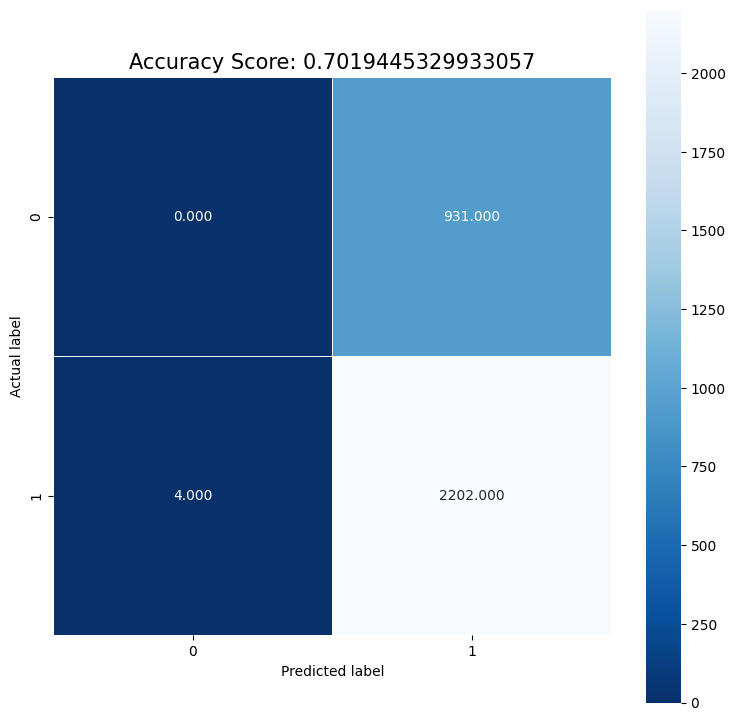

In [24]:
# import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=0.5, square=True, cmap="Blues_r")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
all_sample_title = "Accuracy Score: {0}".format(score)
plt.title(all_sample_title, size=15);

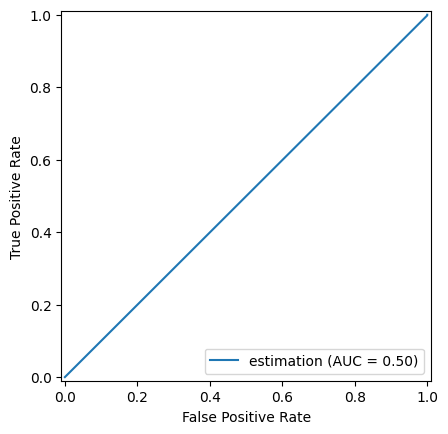

In [25]:
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(
    fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="estimation"
)
display.plot()
plt.show()